# **Financial Asset Data Analysis**

In [1]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yfin

from datetime import date

pd.options.display.float_format = "{:,.6f}".format

## **Equities Data for Amazon and Ford, along with Bitcoin Data**

This is five years of equity price data for Ford and Amazon along with the daily Bitcoin prices over the same time period. The reason I chose Ford and Amazon here is to give examples from different sectors. While Amazon has been around for a while now, it still represents a newer, popular tech stock while Ford is very much part of the old guard, trading publicly since 1956.


In [39]:
# Starting and end dates
start = datetime.date(2019, 8, 1)
end = datetime.date(2024, 8, 1)

# Get Amazon, Ford and Bitcoin data
df = pd.read_csv('stocks_data.csv', index_col='Date', parse_dates=True)\
                    .loc[start:end].reindex(columns=["AMZN", "F", "BTC-USD"])

# Convert DataFrame index to timezone-aware (UTC)
df.index = df.index.tz_localize('UTC')

In [3]:
df.head(10)

,AMZN,F,BTC-USD
Date,,,
2019-08-01 00:00:00+00:00,92.765999,6.833697,"10,399.668945"
2019-08-02 00:00:00+00:00,91.162003,6.811677,"10,518.174805"
2019-08-03 00:00:00+00:00,NaN,NaN,"10,821.726562"
2019-08-04 00:00:00+00:00,NaN,NaN,"10,970.184570"
2019-08-05 00:00:00+00:00,88.256500,6.774976,"11,805.653320"
2019-08-06 00:00:00+00:00,89.391502,6.958480,"11,478.168945"
2019-08-07 00:00:00+00:00,89.669998,6.995181,"11,941.968750"
2019-08-08 00:00:00+00:00,91.644501,7.017202,"11,966.407227"
2019-08-09 00:00:00+00:00,90.378998,6.936460,"11,862.936523"


In [4]:
df.describe()

,AMZN,F,BTC-USD
count,"1,258.000000","1,258.000000","1,827.000000"
mean,137.853120,9.445128,"30,854.084965"
std,31.730629,2.873780,"18,350.840533"
min,81.820000,3.042593,"4,970.788086"
25%,107.565500,6.857018,"13,602.354004"
50%,143.729996,9.971506,"28,033.562500"
75%,164.599251,11.059461,"43,593.824219"
max,200.000000,19.209183,"73,083.500000"


## **Digging a Little Deeper into the Data**

Using the *describe()* method to show summary stats of the data, we can see that Bitcoin has a much higher number of observations (count) than our two stocks, which, as just discussed, is because stocks are not traded on weekends. The other summary stats are relatively basic, like mean and standard deviation along with showing minimum, maximum, and a few quantiles. It is hard to compare these investments with this data alone since each asset had a different starting price five years ago so it is better to compare their returns.


Charting Prices over 2023 of the three assets:

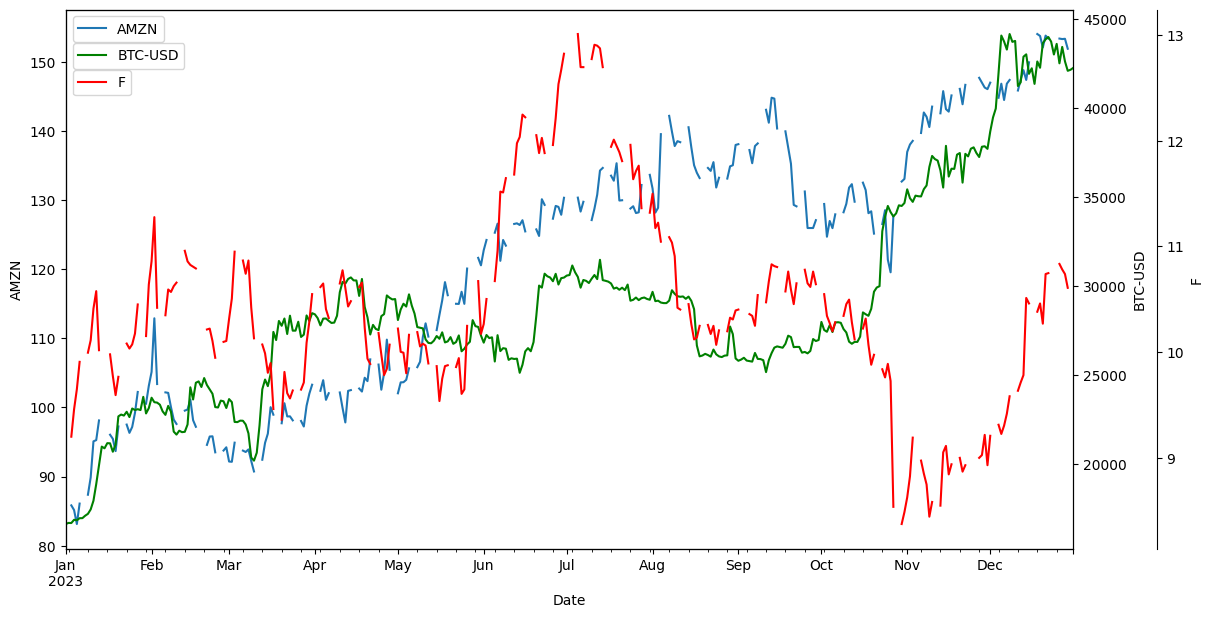

In [5]:
# Create the figure.
# Create a plot where the three assets have the same index (x-axis) but different scale (y-axis)
fig = plt.figure(figsize=(13,7))
ax1 = fig.add_subplot(111)
ax2 = ax1.twinx()
ax3 = ax1.twinx()

# Plot the data
df["2023-01-01":"2023-12-31"].plot(ax=ax1, y='AMZN', legend=True)
df["2023-01-01":"2023-12-31"].plot(ax=ax2, y='BTC-USD', legend=True, color='g')
df["2023-01-01":"2023-12-31"].plot(ax=ax3, y='F', legend=True, color='r')

# We set the labels to the axes
ax1.set_ylabel('AMZN')
ax2.set_ylabel('BTC-USD')
ax3.set_ylabel('F')
ax3.spines['right'].set_position(('outward', 60))

# Set position of legends
ax1.legend(['AMZN'], loc='upper left')
ax2.legend(['BTC-USD'], loc='upper left', bbox_to_anchor=(0, 0.95))
ax3.legend(['F'], loc='upper left', bbox_to_anchor=(0, 0.9))

plt.show()


The above code and chart demonstrate how one can easily pass in a date range to the plot method in order to chart a subset of the data. The figure is the three subplots that share the same x-axis (date) but have different y-axes to plot the prices of Amazon (AMZN), Bitcoin (BTC-USD), and Ford (F) for the year 2023. This approach allows us to visualize the price trends of three different assets with varying scales on the same plot. However, the chart also illustrates why using price alone is not ideal for comparing two assets. The scale of Bitcoin's price versus a low-price stock like Ford makes it very hard to compare the two when deciding which stock is better to invest in.



## **Calculating Return on Investment**

If one invested **\$1,000** into each of these assets five years ago, how much money would we have today? To answer this question, we first need to determine how many shares of each stock we could buy with **\$1,000** at the start of our date range. For the purposes of this project, we will use **01/08/2019** as our starting point.


From our data above, we can see the starting prices of AMZN, F, and Bitcoin. We can also have the values of the first row for each ticker stored in individual variables, which we can then use for further calculations or analysis. We also need to divide **\$1,000** by each of these numbers to see how many shares we will have:

In [6]:
# Access the first row of the DataFrame
first_row = df.iloc[0]

# Assign price values to variables
amzn_price = first_row["AMZN"]
f_price = first_row["F"]
btc_price = first_row["BTC-USD"]

# Print price values
print("Purchase price of AMZN:", np.round(amzn_price, 3))
print("Purchase price of F:", np.round(f_price, 3))
print("Purchase price of BTC-USD:", np.round(btc_price, 3))
print(" - - - - - - - - - -")

# Divide $1,000 by each of price values to get number of shares
amzn_shares = 1000 / amzn_price
f_shares = 1000 / f_price
btc_shares = 1000 / btc_price

# Print number of shares for each ticker
print("Number of shares of AMZN:", np.round(amzn_shares, 3))
print("Number of shares of F:", np.round(f_shares, 3))
print("Number of shares of BTC-USD:", np.round(btc_shares, 3))


Purchase price of AMZN: 92.766
Purchase price of F: 6.834
Purchase price of BTC-USD: 10399.669
 - - - - - - - - - -
Number of shares of AMZN: 10.78
Number of shares of F: 146.334
Number of shares of BTC-USD: 0.096


 Now, to determine how much money we would have today, we look at the most recent date in our dataset (31/07/2024), get the prices of each asset, and multiply our number of shares by this number. Using the *tail()* method, we can find this by looking at the bottom of our dataset. We can also find the asset value at the end of the review period.

In [7]:
# Get last date values from df
last_row = df.iloc[-1]

# Assign end date price values to variables
amzn_price_end = last_row["AMZN"]
f_price_end = last_row["F"]
btc_price_end = last_row["BTC-USD"]

# Print end date prices
print("End price of AMZN:", np.round(amzn_price_end, 3))
print("End price of F:", np.round(f_price_end, 3))
print("End price of BTC-USD:", np.round(btc_price_end, 3))
print(" - - - - - - - - - -")

# Compute end date values for each ticker
amzn_value = amzn_price_end * amzn_shares  # need 20 times multiple due to stock split
f_value = f_price_end * f_shares
btc_value = btc_price_end * btc_shares

# Print end date values
print("Holding value of AMZN:", np.round(amzn_value, 3))
print("Holding value of F:", np.round(f_value, 3))
print("Holding value of BTC-USD:", np.round(btc_value, 3))


End price of AMZN: 186.98
End price of F: 9.786
End price of BTC-USD: 64619.25
 - - - - - - - - - -
Holding value of AMZN: 2015.609
Holding value of F: 1432.036
Holding value of BTC-USD: 6213.587


The investment spend was \$1000 for each ticker. Now based on the computation results above, it seems that our investments have performed differently:

 - AMZN: Our Amazon investment has more than doubled, indicating a significant gain.
 - F: Our Ford investment has also grown, showing a decent return.
 - BTC-USD: Our Bitcoin investment has increased by more than six times, suggesting a substantial profit.


Next we compute a simple return for our assets

In [8]:
# Compute simple returns
amzn_return = (amzn_value - 1000) / 1000
f_return = (f_value - 1000) / 1000
btc_return = (btc_value - 1000) / 1000

# Print the returns
print("Simple return of AMZN:", np.round(amzn_return * 100, 3), "%")
print("Simple return of F:", np.round(f_return * 100, 3), "%")
print("Simple return of BTC-USD:", np.round(btc_return * 100, 3), "%")


Simple return of AMZN: 101.561 %
Simple return of F: 43.204 %
Simple return of BTC-USD: 521.359 %


Bitcoin's return here is off the charts compared to the other two assets. Bitcoin is a relatively new (some would even say riskier) asset than the other two. Higher risk equals higher potential for rewards, and thus far, investing in Bitcoin has paid off handsomely.


##  **Comparing Equities and Bitcoin to Bonds**

Adding one more asset class here: bonds.

Bonds as a financial asset not only have the return of principal, but they also return a coupon, usually annually or quarterly. To simplify things, we will use an exchange-traded fund (ETF), which tracks bonds. The ETF is the Vanguard Long-Term Bond Index Fund ETF or BLV for short. This fund intends to track the performance of the Bloomberg Barclays U.S. Long Government/Credit Float Adjusted Index. This index includes investment grade corporate, U.S. government, and international dollar-denominated bonds that have maturities greater than 10 years. At least 80% of the fund's total assets will be invested in bonds held in the index mentioned above (Vanguard).

The code below pulls BLV data and join it with our current DataFrame, df.

In [9]:
df = df.join(yfin.download(["BLV"], start, end, auto_adjust = False)["Adj Close"].tz_localize('UTC'))
# df = df.join(pd.read_csv('FD_M2_L1_stocks_data.csv', index_col='Date', parse_dates=True)\
#              .loc[start:end].reindex(columns=["BLV"]).tz_localize('UTC'))
df

[*********************100%***********************]  1 of 1 completed


,AMZN,F,BTC-USD,BLV
Date,,,,
2019-08-01 00:00:00+00:00,92.765999,6.833697,"10,399.668945",72.902306
2019-08-02 00:00:00+00:00,91.162003,6.811677,"10,518.174805",73.412727
2019-08-03 00:00:00+00:00,NaN,NaN,"10,821.726562",NaN
2019-08-04 00:00:00+00:00,NaN,NaN,"10,970.184570",NaN
2019-08-05 00:00:00+00:00,88.256500,6.774976,"11,805.653320",74.041504
...,...,...,...,...
2024-07-27 00:00:00+00:00,NaN,NaN,"67,813.335938",NaN
2024-07-28 00:00:00+00:00,NaN,NaN,"68,255.867188",NaN
2024-07-29 00:00:00+00:00,183.199997,9.957947,"66,819.914062",65.534111


### **Calculate Log Returns, Remove Unused Columns, and Drop Nulls**

Before computing returns, we need to remove the nulls for the weekend dates.

In [10]:
# In order to calculate the returns of the stocks, we need to drop the NA rows.
returns_stocks_BLV = df[['AMZN', 'F', 'BLV']].dropna().pct_change()

# Crypto is traded 24/7
returns_BTC = df[['BTC-USD']].pct_change()

# We broadcast the index of crypto on the stocks in order to join the datasets
# having NaN for weekends within stocks and BLV columns
returns_stocks = returns_stocks_BLV.reindex(returns_BTC.index)
returns = returns_BTC.join(returns_stocks_BLV, how = 'outer')[1:]
returns


,BTC-USD,AMZN,F,BLV
Date,,,,
2019-08-02 00:00:00+00:00,0.011395,-0.017291,-0.003222,0.007001
2019-08-03 00:00:00+00:00,0.028860,NaN,NaN,NaN
2019-08-04 00:00:00+00:00,0.013719,NaN,NaN,NaN
2019-08-05 00:00:00+00:00,0.076158,-0.031872,-0.005388,0.008565
2019-08-06 00:00:00+00:00,-0.027740,0.012860,0.027086,0.006694
...,...,...,...,...
2024-07-27 00:00:00+00:00,-0.001454,NaN,NaN,NaN
2024-07-28 00:00:00+00:00,0.006526,NaN,NaN,NaN
2024-07-29 00:00:00+00:00,-0.021038,0.003836,-0.016086,0.003785


### **Show Summary Stats for the Returns**

In [11]:
returns.describe()

,BTC-USD,AMZN,F,BLV
count,"1,826.000000","1,257.000000","1,257.000000","1,257.000000"
mean,0.001579,0.000803,0.000671,-0.000034
std,0.033707,0.022175,0.027760,0.009179
min,-0.371695,-0.140494,-0.183614,-0.075169
25%,-0.013480,-0.011068,-0.013605,-0.005253
50%,0.000234,0.000643,0.000000,0.000572
75%,0.015996,0.012222,0.014212,0.005206
max,0.187465,0.135359,0.234414,0.049139


### **Converting Daily Returns to Annual**

In [12]:
(returns.describe()[["BTC-USD", "F"]])

,BTC-USD,F
count,"1,826.000000","1,257.000000"
mean,0.001579,0.000671
std,0.033707,0.027760
min,-0.371695,-0.183614
25%,-0.013480,-0.013605
50%,0.000234,0.000000
75%,0.015996,0.014212
max,0.187465,0.234414


Since we are using simple returns, in order to properly annualize them, we will use the geometric mean

In [13]:
# Annualize BTC-USD with 365 trading days
(np.prod(returns_BTC + 1, axis=0) ** (1/len(returns_BTC))) ** (365) - 1


,0
BTC-USD,0.440439


In [14]:
# Annualize stocks with 252 trading days
(np.prod(returns_stocks_BLV + 1, axis=0) ** (1/len(returns_stocks_BLV))) ** (252) - 1

,0
AMZN,0.150742
F,0.074584
BLV,-0.018936


We can run the same analysis on BLV as we did on the above stocks to get the total simple return over a five-year period using a slightly different method. This time, we'll calculate the simple return rate and then just multiply \$1,000 initial investment by 1 + `returnRate`.

In [15]:
# Get innitial and end prices from df
blv_price = df.iloc[0]["BLV"]
blv_price_end = df.iloc[-1]["BLV"]

# Compute simple return rate
blv_return_rate = (blv_price_end - blv_price) / blv_price
print("Simple return rate of BLV:", np.round(blv_return_rate * 100, 3), "%")

# Compute total simple return
total_simple_return = 1000 * (1 + blv_return_rate)
print("Total simple return of BLV: $", np.round(total_simple_return, 3))


Simple return rate of BLV: -9.103 %
Total simple return of BLV: $ 908.974


This output indicates that the investment in BLV has experienced a negative simple return of -9.103%. This means we've lost approximately 9.1% of our initial investment in BLV.

If we started with 1,000 USD, after five years, we would've ended up with (1 - 9.103) * 1000 = 908.97 USD.

This is a much lower return than what we would've gotten with Ford, Amazon, or Bitcoin. This is to be expected for the most part as bonds return a quarterly/annual coupon along with returning the principal. For this reason, bonds (especially government bonds) are considered safer assets than stocks or cryptocurrencies.

## **Future Value of an Investment**

### **Pulling 5 years daily price data for S&P 500 and Russell 2000**

We're going to dig deeper into specific equities asset classes and compare them as potential investments. We will start by comparing large cap to small cap stocks using S&P 500 and the Russell 2000 Index.


In [17]:
# Dates
start = datetime.date(2019, 8, 1)
end = datetime.date(2024, 8, 1)


prices = pd.read_csv('stocks_data.csv', index_col='Date', parse_dates=True)\
                        .loc[start:end].reindex(columns=["^GSPC", "^RUT"])

# Rename column to make names more intuitive
prices = prices.rename(columns={"^GSPC": "SP500", "^RUT": "Russell2000"})

# Get dataset stats
prices.describe()

,SP500,Russell2000
count,"1,258.000000","1,258.000000"
mean,"4,028.833253","1,865.957234"
std,685.682781,284.232353
min,"2,237.399902",991.159973
25%,"3,502.235046","1,674.337524"
50%,"4,110.745117","1,873.654968"
75%,"4,468.547485","2,067.780090"
max,"5,667.200195","2,442.739990"


In [18]:
# Display first 5 rows
prices.head()


,SP500,Russell2000
Date,,
2019-08-01,"2,953.560059","1,550.760010"
2019-08-02,"2,932.050049","1,533.660034"
2019-08-03,NaN,NaN
2019-08-04,NaN,NaN
2019-08-05,"2,844.739990","1,487.410034"


Once again, we can see these datasets have different starting points, so the only way we can do a fair comparison is by comparing returns.

### **Calculate Log Returns and Drop Nulls**

Here we have nulls for the weekend dates since the S&P 500 and the Russell 2000 Index are both stock indices. The following code removes nuls with '.df.dropna()' method and calculates the log returns of these financial assets:

In [19]:
# Calculate log returns
prices = prices.dropna()
df = np.log(prices) - np.log(prices.shift(1))
df = df.iloc[1:, 0:]
df.head()


,SP500,Russell2000
Date,,
2019-08-02,-0.007309,-0.011088
2019-08-05,-0.030230,-0.030621
2019-08-06,0.012933,0.009821
2019-08-07,0.000767,-0.000932
2019-08-08,0.018588,0.020734


### **Calculating Future Value of Each Index**

We calculate the average annual return for each index using the mean of the daily returns multiplied by 252 (trading days per year). Then, we use these daily returns to calculate future values.



In [21]:
# Calculate average daily return over the past 5 years
avg_daily_returns = df.mean()

# Calculate future value for each index (using daily returns and 5 years)
num_days = 252 * 5  # Number of trading days in 5 years
future_value_sp500 = 1000 * np.exp(avg_daily_returns["SP500"] * num_days)
future_value_russell2000 = 1000 * np.exp(avg_daily_returns["Russell2000"] * num_days)

print("Future Value of SP500:", future_value_sp500)
print("Future Value of Russell2000:", future_value_russell2000)


Future Value of SP500: 1872.5041981875975
Future Value of Russell2000: 1455.0892174400194


While future value is important when comparing investments, we also need to be concerned about how volatile these investment opportunities are.

## **Volatility Metrics**

### **Price Volatility: High-Low**

We will be comparing the volatility of certain investments. The first method is comparing the high and low of the index. For this, we use the `max()` and `min()` methods to get the high and low of the price over the duration of the DataFrame by column. From here, we can subtract these from each other to get an idea of the potential volatility of each investment.

In [22]:
prices.max()

,0
SP500,"5,667.200195"
Russell2000,"2,442.739990"


In [23]:
prices.min()

,0
SP500,"2,237.399902"
Russell2000,991.159973


In [24]:
prices.max() - prices.min()

,0
SP500,"3,429.800293"
Russell2000,"1,451.580017"


Now let's look at the same metric over the last year of the data.

In [25]:
# Slice last year from prices data
end = pd.Timestamp(end).tz_localize(None)  # Remove timezone info

currYear = prices.loc[
    pd.Timestamp(end - datetime.timedelta(365)) : end
]

# Calculate the difference between the maximum and minimum values in the currYear
currYear.max() - currYear.min()


,0
SP500,"1,549.830078"
Russell2000,626.729980


Even when comparing data over the last 365 days, it seems hard to do a comparison of these two datasets since they have different starting points. One final adjustment to this volatility metric could be to standardize it by dividing by the current price of the index:

In [26]:
(currYear.max() - currYear.min()) / prices.iloc[-1]

,0
SP500,0.280649
Russell2000,0.277993


Volatility is a measure of the dispersion or fluctuation of returns. Higher volatility indicates greater price swings and potentially higher risk/reward. Now that we have the data standardized by the current price, this high/low metric actually shows that we have similar daily volatility levels in both indices, with the S&P 500 being slightly more volatile than the Russell 2000.

### **Moving Averages**

I am going to create a volatility metric that compares each day's price to the moving average. The 50- and 200-day averages are commonly used when comparing investments. For this metric, I will use the 50-day average.

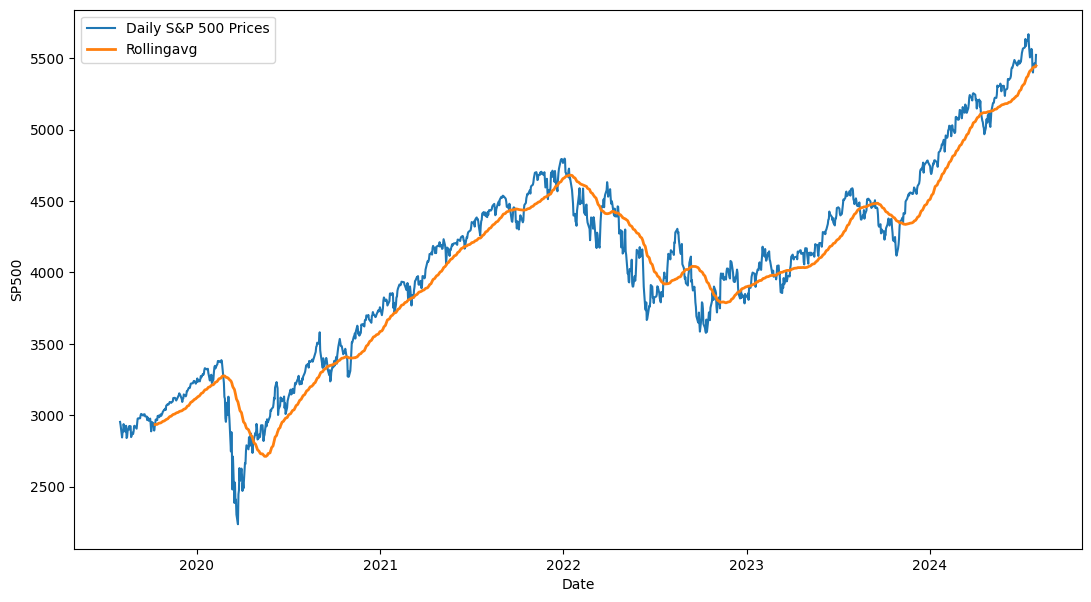

In [27]:
# Calculate the 50-day rolling average of the "SP500" column
prices["SP500 50 day_rolling_avg"] = prices.SP500.rolling(50).mean()

# set figure size and plot a simple time series plot using seaborn.lineplot()
plt.figure(figsize=(13, 7))
sns.lineplot(x="Date", y="SP500", data=prices, label="Daily S&P 500 Prices")

# plot rolling average
sns.lineplot(x="Date", y="SP500 50 day_rolling_avg", data=prices, label="Rollingavg", linewidth=2)
plt.show()

This visualization helps to smooth out short-term fluctuations in daily prices and highlight the longer-term trend of the S&P 500. The rolling average provides a clearer picture of the overall direction of the market.


#### **Rolling Distances**

We can create a volatility metric here using this moving average. Let's imagine we're taking the distance between the moving average line and each data point from the S&P 500 chart. We can use this as a proxy for volatility. We also would want to treat the negative differences the same as the positive differences; otherwise, they may cancel each other out. As such, we will use the absolute value of each point. We will divide these differences by the prices in order to standardize these values, and finally, we'll take the average of those values.

In [28]:
((abs(prices - prices.rolling(50).mean())) / prices).mean()

,0
SP500,0.037068
Russell2000,0.048725
SP500 50 day_rolling_avg,0.028209


The result of this calculation provides a measure of how much, on average, the daily prices deviate from their 50-day rolling average, expressed as a percentage. This can be a useful indicator of the volatility or stability of the asset. Higher values suggest greater fluctuations around the rolling average, while lower values indicate more stable prices.

This is a different metric than the high/low metric we previously calculated, and it shows that the average deviation for the Russell 2000 is more volatile compared to the S&P 500. And the rolling average itself (SP500 50 day_rolling_avg) has an average deviation of 2.82%. This is expected as the rolling average is smoother than the daily prices.

This can be useful for understanding the relative volatility of different assets and how much daily prices tend to deviate from their longer-term trends.


### **Price Volatility: Standard Deviations**


In [29]:
prices.std()

,0
SP500,685.682781
Russell2000,284.232353
SP500 50 day_rolling_avg,635.644388


For a better comparison, we will call this `std()` method on the daily returns of the last 5 years:

In [30]:
df.std()

,0
SP500,0.013458
Russell2000,0.017503


Here again, the Russell 2000 has a slightly higher standard deviation than the S&P 500, suggesting that it has been more volatile over the last 5 years.


### **Writing a Volatility Comparison Function**

To tie it all together, we're going to take the three volatility metrics we've used up to this point, along with average daily return, and write a function, which takes:

* `startTime` - `dateTime` format
* `endTime` - `dateTime` format
* `tickers` - a dictionary of values where the key is the yahoo ticker and the value is the display name i.e. {"^GSPC": "SP500", "^RUT": "Russell2000"}


In [32]:
def investCompare(startTime, endTime, tickers):
    # pull price data from yahoo -- (list(tickers.keys())) = ['^GSPC','^RUT']
    startTime = pd.Timestamp(startTime).tz_localize('UTC')
    endTime = pd.Timestamp(endTime).tz_localize('UTC')


    prices = pd.read_csv('stocks_data.csv', index_col='Date', parse_dates=True)\
                        .tz_localize('UTC').loc[startTime:endTime].reindex(columns=list(tickers.keys()))
    prices = prices.rename(columns=tickers)

    # Compute returns
    returns = np.log(prices) - np.log(prices.shift(1))
    returns = returns.iloc[1:, 0:]

    # pull data into separate DataFrame to just look at the last 365 days of
    # data for calculating our high/low metric
    currYear = prices.loc[(endTime - datetime.timedelta(365))\
                    .tz_convert(prices.index.tz) : endTime.tz_convert(prices.index.tz)]

    # High-Low
    highLow = (currYear.max() - currYear.min()) / prices.iloc[-1]
    highLow = pd.DataFrame(highLow, columns=["HighMinusLow"])

    # Moving average volatility
    MA = pd.DataFrame(
        ((abs(prices - prices.rolling(50).mean())) / prices).mean(),
        columns=["MovingAverageVolatility"],
    )
    investments = pd.merge(highLow, MA, left_index=True, right_index=True)

    # Standard deviation
    investments = pd.merge(
        investments,
        pd.DataFrame(returns.std(), columns=["StandardDeviation"]),
        left_index=True,
        right_index=True,
    )

    # Daily return
    investments = pd.merge(
        investments,
        pd.DataFrame(returns.mean(), columns=["Daily Return Percentage"]),
        left_index=True,
        right_index=True,
    )

    # Format columns:
    # Hogh-Low column rounded to 5 decimal
    investments["HighMinusLow"] = investments["HighMinusLow"].round(4).astype(str)

    # MA, std and returns columns as percentage
    columns = ["MovingAverageVolatility", "StandardDeviation", "Daily Return Percentage"]
    for col in columns:
      investments[col] = (investments[col] * 100).round(3).astype(str) + '%'

    return investments

Here we also format values: High-Low values are rounded to 4 decimal places and the values in the 'MovingAverageVolatility,' 'StandardDeviation,' and 'Daily Return Percentage' columns are formatted as percentages with 3 decimal rounding, which is good practice to facilitate comparison.

In [33]:
investCompare(
    datetime.date(2019, 8, 1),
    datetime.date(2024, 8, 1),
    {"^GSPC": "SP500", "^RUT": "Russell2000"},
)

,HighMinusLow,MovingAverageVolatility,StandardDeviation,Daily Return Percentage
SP500,0.2806,nan%,1.314%,0.058%
Russell2000,0.278,nan%,1.711%,0.036%


I added Apple stock to the DataFrame in order to compare it to the other two indices.

In [34]:
investCompare(
    datetime.date(2019, 8, 1),
    datetime.date(2024, 8, 1),
    {"^GSPC": "SP500", "^RUT": "Russell2000", "AAPL": "Apple"},
)

,HighMinusLow,MovingAverageVolatility,StandardDeviation,Daily Return Percentage
SP500,0.2806,nan%,1.314%,0.058%
Russell2000,0.278,nan%,1.711%,0.036%
Apple,0.3154,nan%,1.957%,0.104%


These metrics show Apple to be a better investment in terms of daily return, but they also show that Apple is significantly more volatile than the two indices. This is expected, since the indices represent vast baskets of stocks. With many stocks moving in different directions, you'd expect the indices to be less volatile than an individual stock, even a blue-chip stock like Apple.

# **Comparing Growth vs. Value Stocks**
I used Vanguard Growth ETF (VUG) for the growth stock and Vanguard Value ETF (VTV) for the value stock

In [35]:
# Set start and end dates
start = datetime.date(2022, 8, 1)
end = datetime.date(2024, 8, 1)

# Compute investments stats using investCompare() function
investCompare(start, end, {"VUG": "Growth", "VTV": "Value"})


,HighMinusLow,MovingAverageVolatility,StandardDeviation,Daily Return Percentage
Growth,0.3582,nan%,1.352%,0.064%
Value,0.2306,nan%,0.857%,0.039%


Running `investCompare` function over the last two years for these ETFs shows that growth stocks have clearly outperformed value stocks in terms of returns — but not without increased volatility.

Let's take a look at the data since 2010 for a longer term comparison:

In [36]:
# Set start and end dates
start = datetime.date(2010, 8, 1)
end = datetime.date(2024, 8, 1)

# Compute investments stats using investCompare() function
investCompare(start, end, {"VUG": "Growth", "VTV": "Value"})


,HighMinusLow,MovingAverageVolatility,StandardDeviation,Daily Return Percentage
Growth,0.3582,2.847%,1.194%,0.065%
Value,0.2306,2.825%,1.018%,0.051%


Interestingly, compared to the previous analysis over a shorter timeframe, the differences in volatility and returns between Growth and Value seem to have narrowed slightly over this longer period. This could be due to the fact that, over the long term, the risk-return profiles of these investment styles are more balanced.



# **Comparing Domestic vs. Foreign Stocks**

I used the S&P 500 for U.S. stocks, SPDR Portfolio Europe ETF (SPEU) for Europe stocks, and SPDR S&P China ETF (GXC) for China stocks.

In [37]:
# Comparing Domestic vs. Foreign Stocks
start = datetime.date(2022, 8, 1)
end = datetime.date(2024, 8, 1)
investCompare(start, end,{"^GSPC": "SP500", "SPEU": "Europe ETF", "GXC": "China ETF"})


,HighMinusLow,MovingAverageVolatility,StandardDeviation,Daily Return Percentage
SP500,0.2806,nan%,1.033%,0.045%
Europe ETF,0.2324,nan%,1.095%,0.051%
China ETF,0.2629,nan%,1.626%,-0.001%


Key Takeaways:

 - The China ETF appears to be the most volatile and risky investment among the three, with a negative average daily return during this period.
 - The Europe ETF and the U.S. stocks show similar levels of volatility and positive returns, with the U.S. stocks having a slightly higher return.

Now, let's zoom out and look at the data since 2010:

In [38]:
# Comparing Domestic vs. Foreign Stocks
start = datetime.date(2010, 8, 1)
end = datetime.date(2024, 8, 1)
investCompare(start, end,{"^GSPC": "SP500", "SPEU": "Europe ETF", "GXC": "China ETF"})


,HighMinusLow,MovingAverageVolatility,StandardDeviation,Daily Return Percentage
SP500,0.2806,2.655%,1.06%,0.051%
Europe ETF,0.2324,3.191%,1.229%,0.037%
China ETF,0.2629,3.928%,1.526%,0.026%


**Key Takeaways:**

 - Over this longer period, the U.S. equities appear to have provided the highest returns, followed by the Europe ETF and then the China ETF.
 - The China ETF, while still showing higher volatility, has a positive average daily return over the long term, unlike the negative return observed in the shorter timeframe analysis.